# Notebook 07 — Panorama: muogramas + mapa para los 4 volcanes

Recorre los 4 volcanes objetivo (`fuego`, `acatenango`, `pacaya`, `agua`) generando
sus muogramas (DEM + cono) desde la estación INSIVUMEH-RSN más cercana, y produce
dos figuras resumen para el paper:

1. **`fig_panorama_residuals.png`** — 4 paneles 2×2 del residuo $\Delta L = L_{DEM} - L_{cono}$ por volcán.
2. **`fig_station_map.png`** — mapa regional con DEM hillshade, cráteres y estaciones RSN coloreadas por volcán.

Más una **tabla resumen** con peak opacidad, residuo medio y fracción del cielo bloqueado por cada volcán.

Todos los parámetros vienen de `data/volcanoes.yaml` y `data/detector_sites.csv` — no hay
nada hardcodeado por volcán.

In [21]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource
from pyproj import Transformer

from analysis.muograma import (
    DEMTerrain, ConicalVolcano, rock_opacity_grid, transmission_map,
)

In [22]:
# Load configs
with open(REPO_ROOT / "data" / "volcanoes.yaml") as f:
    VOLCANOES = yaml.safe_load(f)
sites = pd.read_csv(REPO_ROOT / "data" / "detector_sites.csv")
rsn = pd.read_csv(REPO_ROOT / "data" / "insivumeh_rsn_stations.csv")

DEM_FILE = REPO_ROOT / "data" / "dem" / "Copernicus_DSM_COG_10_N14_00_W091_00_DEM.tif"
if not DEM_FILE.exists():
    raise FileNotFoundError(f"Falta {DEM_FILE}. Corré `make download-dem`.")

print(f"Volcanes objetivo: {list(VOLCANOES.keys())}")
print(f"Detector sites curados (data/detector_sites.csv): {len(sites)} filas")
print(f"Estaciones RSN totales: {len(rsn)}")

Volcanes objetivo: ['fuego', 'acatenango', 'pacaya', 'agua']
Detector sites curados (data/detector_sites.csv): 14 filas
Estaciones RSN totales: 32


## 1. Recorrer los 4 volcanes — compute pipeline

Por cada volcán: terrain → posición del detector (estación default del YAML) → ray-tracing
DEM + cono → residuo + transmisión. Se guarda todo en un dict `results[volcan]` para reusar
en las figuras de abajo. ~30 s total.

In [23]:
results = {}
for volcan, cfg in VOLCANOES.items():
    print(f"\n=== {volcan.upper()} ===")

    # Terrain centered on this volcano's crater
    terrain = DEMTerrain(DEM_FILE,
                         origin_lonlat=(cfg['lon'], cfg['lat']),
                         density_gcc=cfg['cone']['density_gcc'])

    # Detector position: default station from the YAML
    station_code = cfg['default_station']
    station = sites[(sites['target_volcan'] == volcan) & (sites['name'] == station_code)]
    if station.empty:
        print(f"  ⚠ no hay {station_code} para {volcan} en data/detector_sites.csv, skip")
        continue
    station = station.iloc[0]

    _tx = Transformer.from_crs("EPSG:4326", f"EPSG:{terrain.utm_epsg}", always_xy=True)
    e_utm, n_utm = _tx.transform(station['lon'], station['lat'])
    det_x = float(e_utm - terrain.origin_utm[0])
    det_y = float(n_utm - terrain.origin_utm[1])
    det_z = float(terrain.elevation_at(np.array(det_x), np.array(det_y))) + 2.0
    detector_xyz = (det_x, det_y, det_z)

    # Summit view (math convention azimuth, 0°=E)
    summit_z = terrain.summit_elevation
    dx, dy, dz = -det_x, -det_y, summit_z - det_z
    dist_horiz = np.hypot(dx, dy)
    phi_summit = np.degrees(np.arctan2(dy, dx)) % 360
    theta_summit = 90.0 - np.degrees(np.arctan2(dz, dist_horiz))

    # Angular grid (centered on crater direction)
    theta_deg = np.arange(40.0, 85.5, 0.5)
    phi_deg = np.arange(phi_summit - 60.0, phi_summit + 60.5, 0.5)
    theta_rad = np.radians(theta_deg)
    phi_rad = np.radians(phi_deg)

    # Ray tracing: DEM + synthetic cone for residual
    L_dem = rock_opacity_grid(terrain, detector_xyz, theta_rad, phi_rad,
                              max_length_m=8_000.0, n_steps=400)
    cone = ConicalVolcano((0, 0, summit_z),
                          float(cfg['cone']['base_m']),
                          float(cfg['cone']['base_radius_m']),
                          float(cfg['cone']['density_gcc']))
    L_cone = rock_opacity_grid(cone, detector_xyz, theta_rad, phi_rad,
                               max_length_m=8_000.0, n_steps=400)
    delta_L = L_dem - L_cone
    T_dem = transmission_map(L_dem, theta_rad)

    results[volcan] = dict(
        cfg=cfg, station=station,
        detector_xyz=detector_xyz, summit_z=summit_z,
        theta_deg=theta_deg, phi_deg=phi_deg,
        theta_summit=theta_summit, phi_summit=phi_summit,
        L_dem=L_dem, L_cone=L_cone, delta_L=delta_L, T_dem=T_dem,
    )
    print(f"  Detector @ {station['name']} ({station['dist_km']:.2f} km del cráter)")
    print(f"  L_max DEM = {L_dem.max():.0f} g/cm²,"
          f"  ⟨ΔL⟩ = {delta_L[(L_dem>0)&(L_cone>0)].mean():+.0f} g/cm²,"
          f"  T<0.5 = {(T_dem<0.5).mean():.1%}")


=== FUEGO ===
  Detector @ FG16 (3.72 km del cráter)
  L_max DEM = 2093500 g/cm²,  ⟨ΔL⟩ = +814164 g/cm²,  T<0.5 = 33.4%

=== ACATENANGO ===
  Detector @ FG16 (5.79 km del cráter)
  L_max DEM = 2093500 g/cm²,  ⟨ΔL⟩ = +1399301 g/cm²,  T<0.5 = 34.0%

=== PACAYA ===
  Detector @ PCG (1.62 km del cráter)
  L_max DEM = 662500 g/cm²,  ⟨ΔL⟩ = +306460 g/cm²,  T<0.5 = 44.8%

=== AGUA ===
  Detector @ SAOB (5.78 km del cráter)
  L_max DEM = 2114700 g/cm²,  ⟨ΔL⟩ = +1118564 g/cm²,  T<0.5 = 13.4%


## 2. Figura panorama — residuo $\Delta L$ para los 4 volcanes

2×2 paneles, escala de color común (basada en el percentil 99 del máximo absoluto entre
los 4). El cruce negro marca la dirección del cráter desde la estación correspondiente.

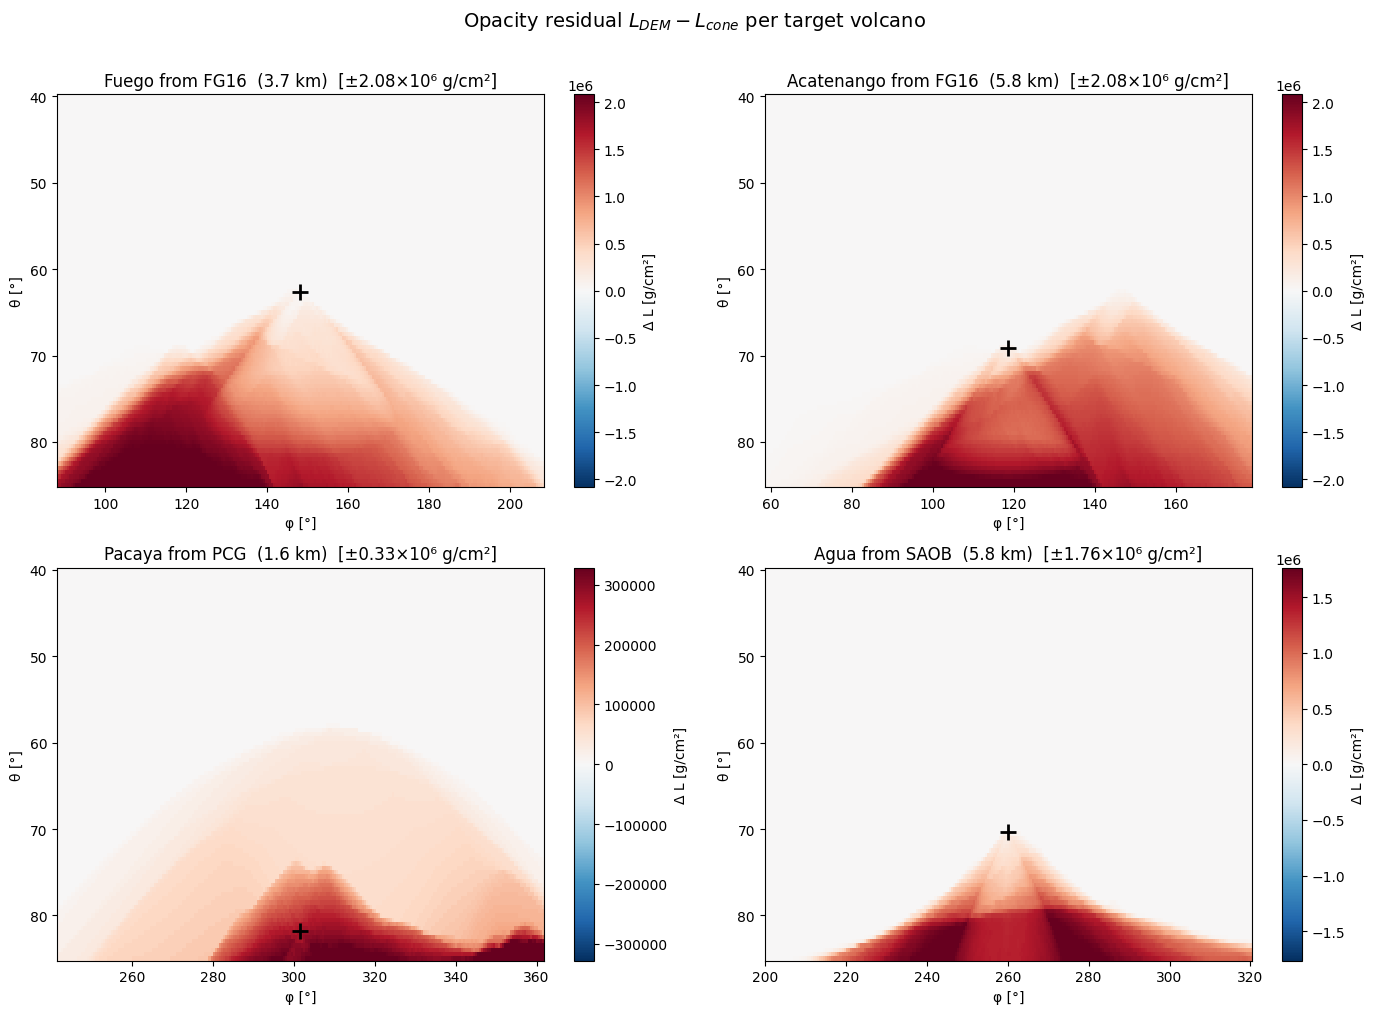

In [24]:
# Per-panel colour scale: each volcano uses its own p99 so that
# low-amplitude cases (Pacaya, Agua) are fully visible.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (volcan, r) in zip(axes.flat, results.items()):
    PHI, THETA = np.meshgrid(r['phi_deg'], r['theta_deg'])
    vmax_i = np.percentile(np.abs(r['delta_L']), 99)
    im_i = ax.pcolormesh(PHI, THETA, r['delta_L'], cmap='RdBu_r',
                         vmin=-vmax_i, vmax=vmax_i, shading='auto')
    ax.scatter(r['phi_summit'], r['theta_summit'], marker='+', s=140, color='black', lw=2)
    ax.set_xlabel('φ [°]'); ax.set_ylabel('θ [°]')
    ax.invert_yaxis()
    ax.set_title(f"{volcan.title()} from {r['station']['name']}"
                 f"  ({r['station']['dist_km']:.1f} km)"
                 f"  [±{vmax_i/1e6:.2f}×10⁶ g/cm²]")
    plt.colorbar(im_i, ax=ax, label='Δ L [g/cm²]')

fig.suptitle('Opacity residual $L_{DEM} - L_{cone}$ per target volcano', fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(REPO_ROOT / 'docs/paper/figures' / 'fig_panorama_residuals.png',
            bbox_inches='tight', dpi=300)
plt.show()

## 3. Tabla resumen — observables clave por volcán

Lista los valores que iban a `Table 3.4` del paper (peak opacidad DEM, peak cono, residuo medio,
fracción de FoV con $T<0.5$ y fracción de cielo abierto).

In [25]:
def in_both(r): return (r['L_dem'] > 0) & (r['L_cone'] > 0)

summary = pd.DataFrame([
    {
        'volcán': v.title(),
        'estación': r['station']['name'],
        'd [km]':   round(r['station']['dist_km'], 2),
        'L_max DEM [g/cm²]':  int(round(r['L_dem'].max())),
        'L_max cone [g/cm²]': int(round(r['L_cone'].max())),
        '⟨ΔL⟩ [g/cm²]':       int(round(r['delta_L'][in_both(r)].mean())),
        'T<0.5':              f"{(r['T_dem'] < 0.5).mean():.1%}",
        'T>0.99':             f"{(r['T_dem'] > 0.99).mean():.1%}",
    }
    for v, r in results.items()
])
print(summary.to_string(index=False))
summary.to_csv(REPO_ROOT / 'docs/paper' / 'panorama_summary.csv', index=False)
print(f"\nGuardado: docs/paper/panorama_summary.csv")

    volcán estación  d [km]  L_max DEM [g/cm²]  L_max cone [g/cm²]  ⟨ΔL⟩ [g/cm²] T<0.5 T>0.99
     Fuego     FG16    3.72            2093500              577700        814164 33.4%  66.5%
Acatenango     FG16    5.79            2093500              773800       1399301 34.0%  66.0%
    Pacaya      PCG    1.62             662500               63600        306460 44.8%  55.1%
      Agua     SAOB    5.78            2114700              742000       1118564 13.4%  86.6%

Guardado: docs/paper/panorama_summary.csv


## 4. Mapa regional — volcanes y estaciones RSN

DEM como hillshade (±25 km del centroide de los 4 volcanes), con:

- ★ cráteres marcados por color
- ● estaciones INSIVUMEH-RSN dentro de 15 km de algún volcán objetivo (color = volcán al que sirve)
- ─── líneas de vista detector-default → cráter

Centroide: (14.4550, -90.7750)


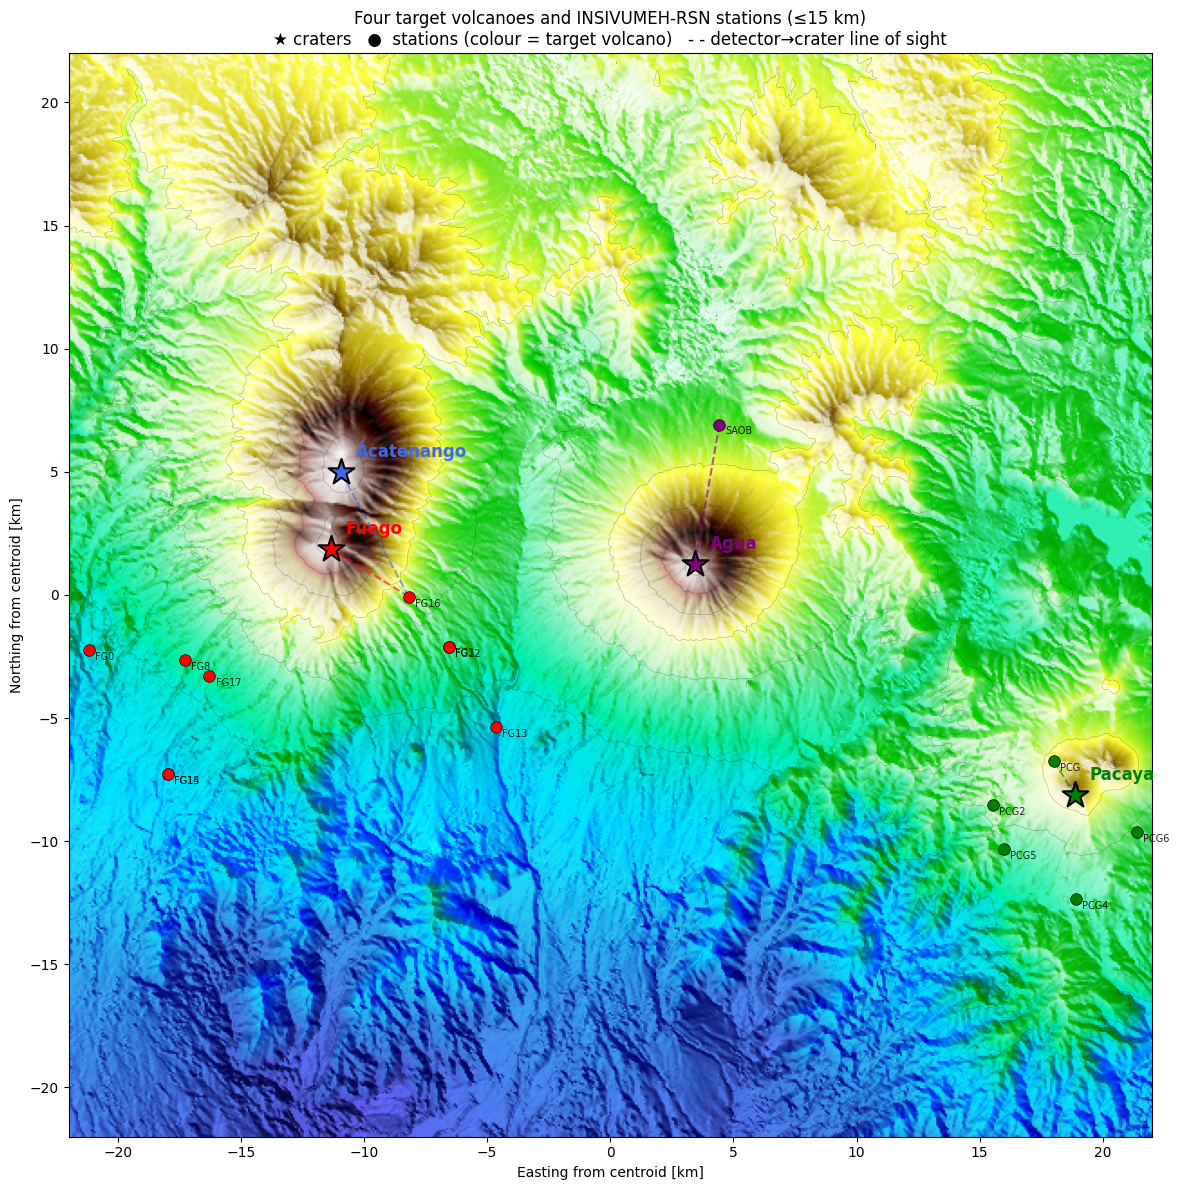


Mapa generado: 15 estaciones graficadas


In [26]:
# Centroide aproximado de los 4 volcanes
CENTROID_LAT = sum(c['lat'] for c in VOLCANOES.values()) / len(VOLCANOES)
CENTROID_LON = sum(c['lon'] for c in VOLCANOES.values()) / len(VOLCANOES)
print(f"Centroide: ({CENTROID_LAT:.4f}, {CENTROID_LON:.4f})")

map_terrain = DEMTerrain(DEM_FILE, origin_lonlat=(CENTROID_LON, CENTROID_LAT), density_gcc=2.65)

extent_m = 22_000   # ±22 km window
xs = np.linspace(-extent_m, extent_m, 600)
ys = np.linspace(-extent_m, extent_m, 600)
X, Y = np.meshgrid(xs, ys)
Z = map_terrain.elevation_at(X, Y)

ls = LightSource(azdeg=315, altdeg=45)
rgb = ls.shade(Z, cmap=plt.cm.terrain, vert_exag=2.0, blend_mode='overlay')

# Projector: lat/lon -> local UTM coords (km, relative to centroid)
_tx = Transformer.from_crs("EPSG:4326", f"EPSG:{map_terrain.utm_epsg}", always_xy=True)
def project(lon, lat):
    e, n = _tx.transform(lon, lat)
    return (e - map_terrain.origin_utm[0]) / 1000, (n - map_terrain.origin_utm[1]) / 1000

colors_vol = {'fuego': 'red', 'acatenango': 'royalblue', 'pacaya': 'green', 'agua': 'purple'}

fig, ax = plt.subplots(figsize=(14, 12))
ax.imshow(rgb, extent=[-extent_m/1000, extent_m/1000]*2, origin='lower')

# Contornos de elevación
cs = ax.contour(X/1000, Y/1000, Z, levels=np.arange(1000, 4500, 500),
                colors='k', linewidths=0.3, alpha=0.4)

# Cráteres (estrellas grandes)
for v, cfg in VOLCANOES.items():
    x, y = project(cfg['lon'], cfg['lat'])
    ax.scatter(x, y, marker='*', s=380, color=colors_vol[v],
               edgecolor='black', linewidth=1.5, zorder=10)
    ax.annotate(v.title(), (x, y), xytext=(x + 0.6, y + 0.6),
                fontsize=12, fontweight='bold', color=colors_vol[v])

# Estaciones RSN cercanas a algún volcán (≤15 km)
plotted = set()
for _, s in rsn.iterrows():
    nearest_v = min(VOLCANOES, key=lambda v: s[f'd_{v}'])
    if s[f'd_{nearest_v}'] > 15:
        continue
    if s['code'] in plotted:
        continue
    x, y = project(s['lon'], s['lat'])
    ax.scatter(x, y, marker='o', s=70, color=colors_vol[nearest_v],
               edgecolor='black', linewidth=0.5, zorder=8)
    ax.annotate(s['code'], (x, y), xytext=(x + 0.25, y - 0.4),
                fontsize=7, color='black', alpha=0.85)
    plotted.add(s['code'])

# Líneas de vista detector-default → cráter
for v, cfg in VOLCANOES.items():
    sc = cfg['default_station']
    s = rsn[rsn['code'] == sc]
    if s.empty:
        continue
    s = s.iloc[0]
    x1, y1 = project(s['lon'], s['lat'])
    x2, y2 = project(cfg['lon'], cfg['lat'])
    ax.plot([x1, x2], [y1, y2], color=colors_vol[v], lw=1.5, alpha=0.6,
            linestyle='--', zorder=6)

ax.set_xlabel('Easting from centroid [km]')
ax.set_ylabel('Northing from centroid [km]')
ax.set_title(f'Four target volcanoes and INSIVUMEH-RSN stations (≤15 km)\n'
             f'★ craters   ●  stations (colour = target volcano)   '
             f'- - detector→crater line of sight')
ax.set_aspect('equal')
ax.set_xlim(-extent_m/1000, extent_m/1000)
ax.set_ylim(-extent_m/1000, extent_m/1000)
plt.tight_layout()
fig.savefig(REPO_ROOT / 'docs/paper/figures' / 'fig_station_map.png',
            bbox_inches='tight', dpi=300)
plt.show()

print(f"\nMapa generado: {len(plotted)} estaciones graficadas")

## Observaciones

Lo que típicamente se ve en el residuo panorama:

- **Fuego**: anillo bipolar + franja roja al N (contaminación de Acatenango)
- **Acatenango**: simétrico al de Fuego — franja roja al S (Fuego asoma)
- **Pacaya**: residuo más limpio (no hay volcán vecino)
- **Agua**: cono casi simétrico — residuo dominado por el corte basal y barrancos reales

Y en el mapa:

- Los 4 volcanes están en una franja N-S de ~12 km en el cuadrante SE del país
- La red RSN cubre Fuego (9 estaciones) y Pacaya (5) densamente; Acatenango comparte la red de Fuego (FG##); Agua tiene solo SAOB.
- Las líneas de vista detector→cráter cruzan terreno claramente trazado en el hillshade — visualmente evidente cuál es el flanco a atravesar.